# Phase 2 — Medical Label Generation
## Blood Vessel Blockage Detection Project

**Goal:** Dataset mein `blockage` label nahi hai — toh hum medical thresholds use karke labels banayenge.

**Approach:** Multi-criteria clinical scoring system
- Har feature ke liye medical threshold set karo
- Har patient ko score do
- Score ke basis pe label assign karo: `0 = Normal`, `1 = Blockage`

In [3]:
from google.colab import files
read = files.upload()

Saving phase1_clean_data.csv to phase1_clean_data.csv


In [4]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


---
## Step 1 — Load Phase 1 Clean Data

In [5]:
df = pd.read_csv('phase1_clean_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 15)


,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv,velocity_ratio,thermal_stress,cardiac_load,vascular_resistance,flow_efficiency
0,83.085284,0.696231,96.250183,36.574682,2.407925,6.796991,69.0,2.298226,0.196088,48.0,0.863222,16.366643,158.577612,0.136523,1.394930
1,129.254272,0.853361,64.919065,35.725150,3.708868,20.324207,113.0,0.840300,0.288642,24.0,1.991006,75.379801,94.953946,0.246316,0.574505
2,105.756839,0.836293,64.084861,35.936101,4.405234,10.418063,86.0,1.151399,0.293710,56.0,1.650262,45.894002,99.020324,0.245627,0.745173
3,133.971340,0.688480,69.625238,36.118859,3.347995,8.783595,94.0,1.752332,0.278041,50.0,1.924178,29.407435,164.719245,0.191426,0.740694
4,105.756839,0.696231,70.038666,36.995431,2.841834,5.616955,61.0,1.725171,0.212553,78.0,1.509978,15.962453,105.235446,0.147986,1.148175


In [6]:
df.describe()

,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv,velocity_ratio,thermal_stress,cardiac_load,vascular_resistance,flow_efficiency
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,107.089004,0.716309,66.098705,36.317124,3.240558,9.616208,81.257500,1.420381,0.247844,51.126000,1.791239,33.224249,111.551284,0.180890,0.848081
std,19.694500,0.100313,16.466481,0.473871,0.648404,4.731442,11.912111,0.528367,0.041923,17.812826,0.803102,21.884000,35.646246,0.054148,0.290627
min,70.008776,0.550020,25.039128,35.035140,2.000465,3.004286,60.000000,0.306204,0.180036,10.000000,0.712304,6.227817,28.550176,0.100594,0.222261
25%,92.214122,0.639752,55.239870,36.017907,2.769359,6.149594,73.000000,1.013533,0.218795,39.000000,1.233454,16.601986,86.128482,0.136202,0.641377
50%,105.756839,0.696231,64.919065,36.409185,3.202267,8.145408,80.500000,1.372918,0.239528,50.000000,1.586450,25.875048,110.186782,0.170990,0.823871
75%,119.855510,0.788756,76.916247,36.673085,3.666738,11.990704,89.000000,1.775725,0.273730,63.000000,2.104052,44.306592,136.232460,0.213755,1.051989
max,159.773470,0.949591,99.994858,37.098756,4.991122,20.752369,113.000000,2.499089,0.356134,89.000000,6.282313,103.421749,207.281110,0.337980,1.634075


---
## Step 2 — Medical Threshold Reference

**Clinical literature se thresholds:**

| Feature | Normal Range | Blockage Indicator |
|---|---|---|
| PSV (Peak Systolic Velocity) | 70-125 cm/s | > 125 cm/s = stenosis |
| RI (Resistive Index) | < 0.75 | > 0.75 = obstruction |
| BFV (Blood Flow Velocity) | > 70 cm/s | < 70 cm/s = reduced flow |
| ColdSpot Area% | < 12% | > 12% = poor perfusion |
| Temperature Difference | < 3.5°C | > 3.5°C = ischemia risk |
| PTT (Pulse Transit Time) | < 0.28 sec | > 0.28 = arterial stiffness |
| PA (Pulse Amplitude) | > 1.2 mmHg | < 1.2 = weak pulse |
| HRV | > 40 ms | < 40 ms = poor cardiac health |

In [7]:
# Medical thresholds
thresholds = {
    'peak_systolic_velocity' : {'threshold': 125,  'condition': 'above', 'weight': 2, 'name': 'PSV'},
    'resistive_index'        : {'threshold': 0.75, 'condition': 'above', 'weight': 2, 'name': 'RI'},
    'blood_flow_velocity'    : {'threshold': 70,   'condition': 'below', 'weight': 2, 'name': 'BFV'},
    'cold_spot_area_percent' : {'threshold': 12,   'condition': 'above', 'weight': 2, 'name': 'CSA'},
    'temperature_difference' : {'threshold': 3.5,  'condition': 'above', 'weight': 1, 'name': 'TDiff'},
    'pulse_transit_time'     : {'threshold': 0.28, 'condition': 'above', 'weight': 1, 'name': 'PTT'},
    'pulse_amplitude'        : {'threshold': 1.2,  'condition': 'below', 'weight': 1, 'name': 'PA'},
    'hrv'                    : {'threshold': 40,   'condition': 'below', 'weight': 1, 'name': 'HRV'},
}

print('Thresholds set!')
print(f'Total scoring criteria: {len(thresholds)}')
print(f'Max possible score: {sum(v["weight"] for v in thresholds.values())}')

Thresholds set!
Total scoring criteria: 8
Max possible score: 12


---
## Step 3 — Check Individual Feature Against Threshold

In [8]:
# Check how many patients cross each threshold
threshold_summary = []

for feat, info in thresholds.items():
    if info['condition'] == 'above':
        count = (df[feat] > info['threshold']).sum()
    else:
        count = (df[feat] < info['threshold']).sum()

    pct = count / len(df) * 100
    threshold_summary.append({
        'Feature'    : info['name'],
        'Condition'  : f"{info['condition']} {info['threshold']}",
        'Weight'     : info['weight'],
        'Count'      : count,
        'Percentage' : round(pct, 1)
    })

summary_df = pd.DataFrame(threshold_summary)
print('Patients crossing each medical threshold:')
summary_df

Patients crossing each medical threshold:


,Feature,Condition,Weight,Count,Percentage
0,PSV,above 125,2,388,19.4
1,RI,above 0.75,2,757,37.8
2,BFV,below 70,2,1193,59.6
3,CSA,above 12,2,499,25.0
4,TDiff,above 3.5,1,620,31.0
5,PTT,above 0.28,1,407,20.3
6,PA,below 1.2,1,693,34.6
7,HRV,below 40,1,515,25.8


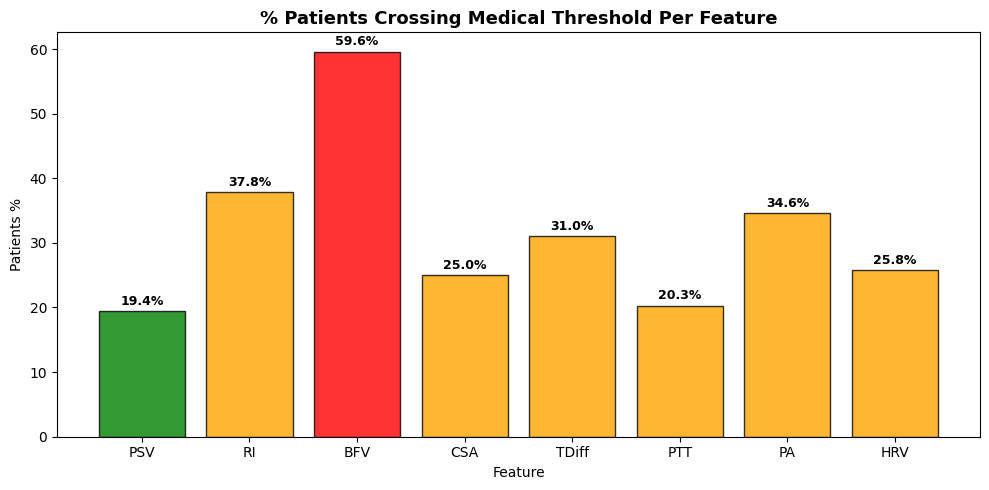

In [9]:
# Visualize threshold crossings
plt.figure(figsize=(10, 5))
colors = ['red' if p > 40 else 'orange' if p > 20 else 'green'
          for p in summary_df['Percentage']]
bars = plt.bar(summary_df['Feature'], summary_df['Percentage'],
               color=colors, edgecolor='black', alpha=0.8)

for bar, val in zip(bars, summary_df['Percentage']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('% Patients Crossing Medical Threshold Per Feature', fontsize=13, fontweight='bold')
plt.ylabel('Patients %')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

---
## Step 4 — Weighted Scoring System

**Why weighted scoring?**
- PSV aur RI are PRIMARY blockage indicators → weight = 2
- HRV aur PA are SECONDARY indicators → weight = 1
- Max score = 12 points
- **Score ≥ 4 = BLOCKAGE** (patient 2+ primary criteria cross karta hai)

In [10]:
# Calculate blockage score for each patient
df['blockage_score'] = 0

for feat, info in thresholds.items():
    if info['condition'] == 'above':
        condition_met = (df[feat] > info['threshold']).astype(int)
    else:
        condition_met = (df[feat] < info['threshold']).astype(int)

    df['blockage_score'] += condition_met * info['weight']

print('Score distribution:')
df['blockage_score'].value_counts().sort_index()

Score distribution:


,count
blockage_score,
0,653
1,54
2,321
3,125
4,114
5,87
6,59
7,88
8,84


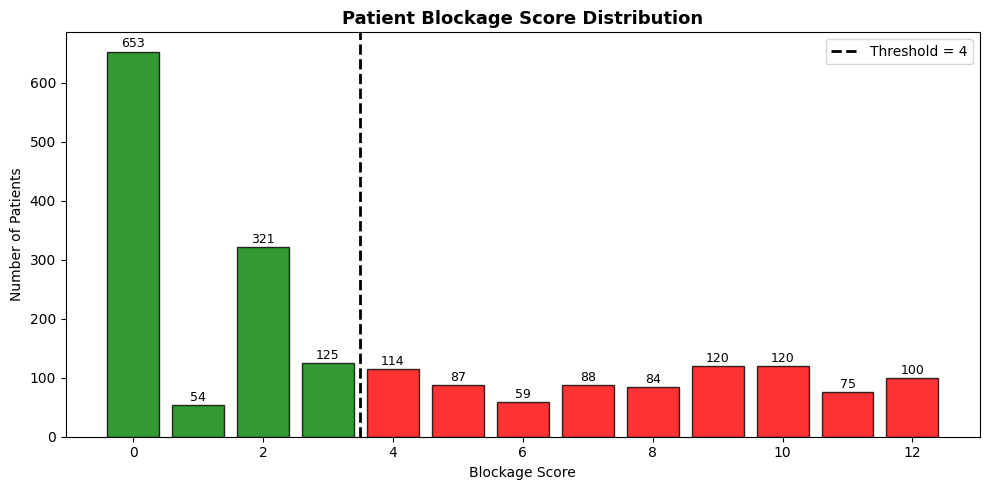

In [20]:
# Score distribution visualization
plt.figure(figsize=(10, 5))
score_counts = df['blockage_score'].value_counts().sort_index()
colors = ['green' if i < 4 else 'red' for i in score_counts.index]
bars = plt.bar(score_counts.index, score_counts.values, color=colors, edgecolor='black', alpha=0.8)

plt.axvline(x=3.5, color='black', linestyle='--', linewidth=2, label='Threshold = 4')
# plt.text(3.7, score_counts.max()*0.9, 'Blockage', color='red', fontsize=11, fontweight='bold')
# plt.text(2.5, score_counts.max()*0.9, 'Normal', color='green', fontsize=11, fontweight='bold')

for bar, val in zip(bars, score_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', va='bottom', fontsize=9)

plt.title('Patient Blockage Score Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Blockage Score')
plt.ylabel('Number of Patients')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Step 5 — Assign Labels

In [21]:
# Assign label based on score
# Score >= 4 = Blockage (1), else Normal (0)
BLOCKAGE_THRESHOLD = 4

df['blockage_label'] = (df['blockage_score'] >= BLOCKAGE_THRESHOLD).astype(int)

print('Label distribution:')
print(df['blockage_label'].value_counts())
print()
print(f'Normal patients  : {(df["blockage_label"]==0).sum()} ({(df["blockage_label"]==0).mean()*100:.1f}%)')
print(f'Blockage patients: {(df["blockage_label"]==1).sum()} ({(df["blockage_label"]==1).mean()*100:.1f}%)')

Label distribution:
blockage_label
0    1153
1     847
Name: count, dtype: int64

Normal patients  : 1153 (57.6%)
Blockage patients: 847 (42.4%)


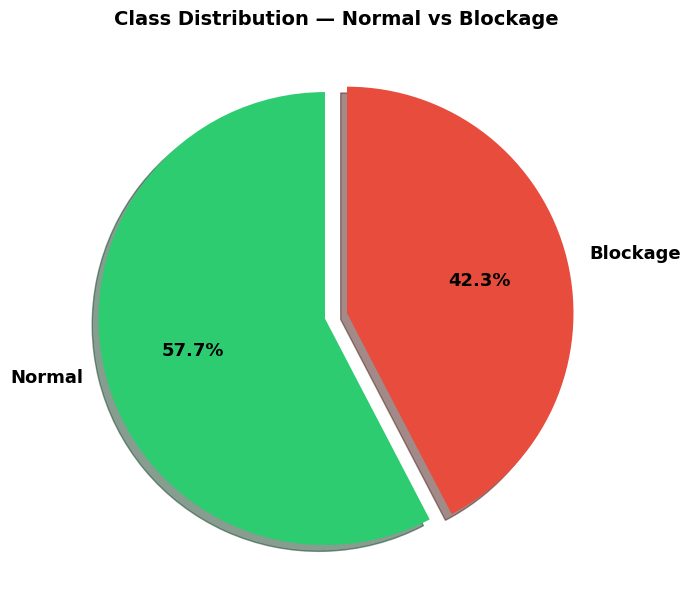

In [22]:
# Pie chart — class distribution
label_counts = df['blockage_label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)

plt.figure(figsize=(7, 7))
plt.pie(label_counts.values, labels=['Normal', 'Blockage'],
        colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 13, 'fontweight': 'bold'},
        shadow=True)
plt.title('Class Distribution — Normal vs Blockage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

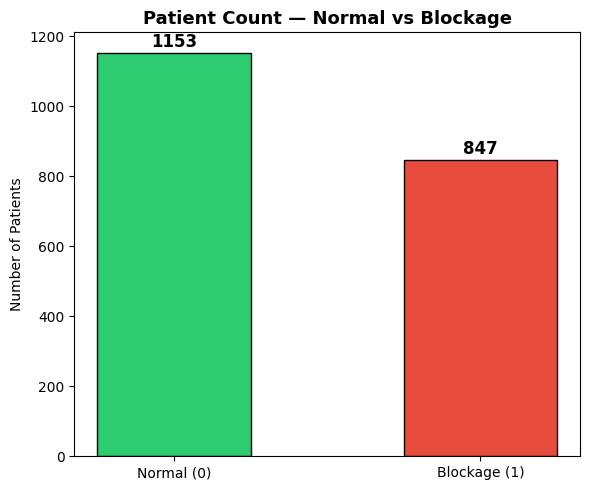

In [23]:
# Count bar chart
plt.figure(figsize=(6, 5))
bars = plt.bar(['Normal (0)', 'Blockage (1)'],
               label_counts.values,
               color=['#2ecc71', '#e74c3c'],
               edgecolor='black', width=0.5)

for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Patient Count — Normal vs Blockage', fontsize=13, fontweight='bold')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

---
## Step 6 — Label Confidence Analysis

**Confidence Levels:**
- **High Confidence** : Score 0-1 (clearly Normal) OR Score 8+ (clearly Blockage)
- **Medium Confidence**: Score 2-3 (borderline Normal) OR Score 6-7
- **Low Confidence**  : Score 4-5 (borderline Blockage — needs doctor review)

In [24]:
# Confidence scoring
def get_confidence(row):
    score = row['blockage_score']
    label = row['blockage_label']

    if label == 0:  # Normal
        if score <= 1:   return 'High'
        elif score <= 2: return 'Medium'
        else:            return 'Low'
    else:           # Blockage
        if score >= 8:   return 'High'
        elif score >= 6: return 'Medium'
        else:            return 'Low'

df['confidence'] = df.apply(get_confidence, axis=1)

print('Confidence distribution:')
df['confidence'].value_counts()

Confidence distribution:


,count
confidence,
High,1206
Medium,468
Low,326


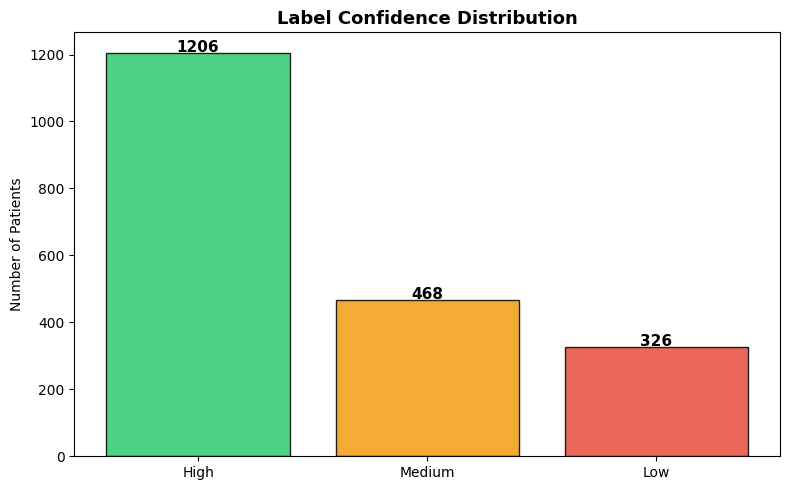

In [25]:
# Confidence visualization
conf_counts = df['confidence'].value_counts()

plt.figure(figsize=(8, 5))
colors_conf = {'High': '#2ecc71', 'Medium': '#f39c12', 'Low': '#e74c3c'}
bars = plt.bar(conf_counts.index, conf_counts.values,
               color=[colors_conf[c] for c in conf_counts.index],
               edgecolor='black', alpha=0.85)

for bar, val in zip(bars, conf_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', fontsize=11, fontweight='bold')

plt.title('Label Confidence Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

---
## Step 7 — Feature Distribution: Normal vs Blockage

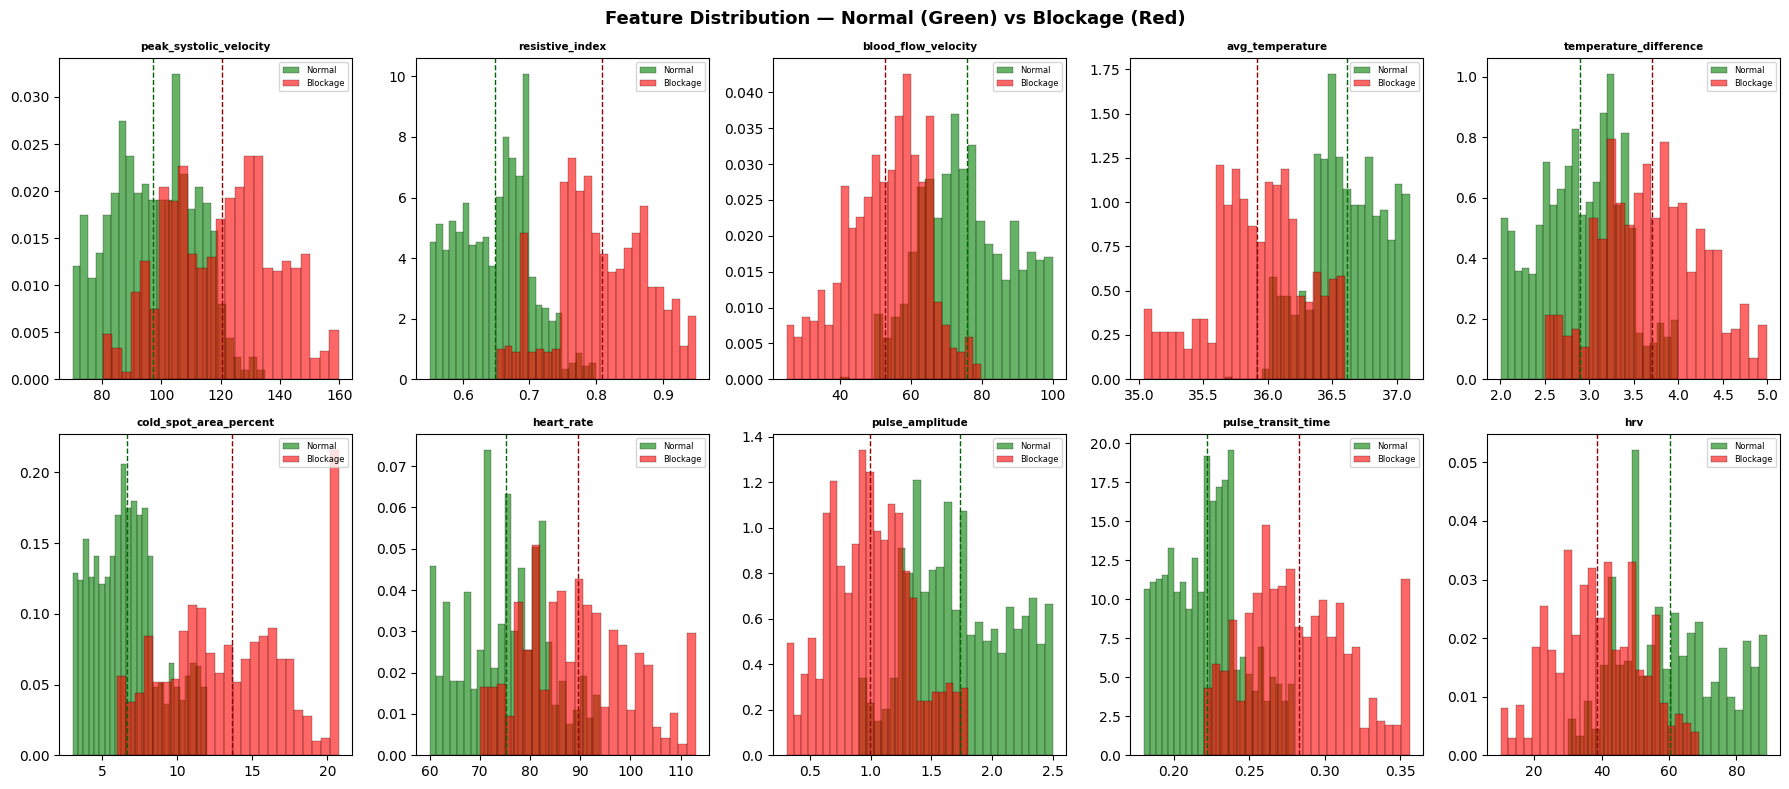

In [26]:
# Compare feature distributions for Normal vs Blockage patients
original_features = ['peak_systolic_velocity','resistive_index','blood_flow_velocity',
                     'avg_temperature','temperature_difference','cold_spot_area_percent',
                     'heart_rate','pulse_amplitude','pulse_transit_time','hrv']

normal   = df[df['blockage_label'] == 0]
blockage = df[df['blockage_label'] == 1]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(original_features):
    axes[i].hist(normal[col],   bins=25, alpha=0.6, color='green', label='Normal',   density=True, edgecolor='black', linewidth=0.3)
    axes[i].hist(blockage[col], bins=25, alpha=0.6, color='red',   label='Blockage', density=True, edgecolor='black', linewidth=0.3)
    axes[i].set_title(col, fontsize=7.5, fontweight='bold')
    axes[i].legend(fontsize=6)
    axes[i].axvline(normal[col].mean(),   color='darkgreen', linestyle='--', linewidth=1)
    axes[i].axvline(blockage[col].mean(), color='darkred',   linestyle='--', linewidth=1)

plt.suptitle('Feature Distribution — Normal (Green) vs Blockage (Red)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# Mean comparison table
mean_comparison = pd.DataFrame({
    'Normal Mean'   : normal[original_features].mean().round(3),
    'Blockage Mean' : blockage[original_features].mean().round(3),
})
mean_comparison['Difference'] = (mean_comparison['Blockage Mean'] - mean_comparison['Normal Mean']).round(3)
mean_comparison['Significant?'] = mean_comparison['Difference'].abs() > mean_comparison['Normal Mean'].abs() * 0.1
mean_comparison

,Normal Mean,Blockage Mean,Difference,Significant?
peak_systolic_velocity,97.270,120.456,23.186,True
resistive_index,0.648,0.809,0.161,True
blood_flow_velocity,75.851,52.824,-23.027,True
avg_temperature,36.614,35.913,-0.701,False
temperature_difference,2.898,3.707,0.809,True
cold_spot_area_percent,6.655,13.648,6.993,True
heart_rate,75.134,89.594,14.460,True
pulse_amplitude,1.734,0.993,-0.741,True
pulse_transit_time,0.222,0.283,0.061,True
hrv,60.328,38.600,-21.728,True


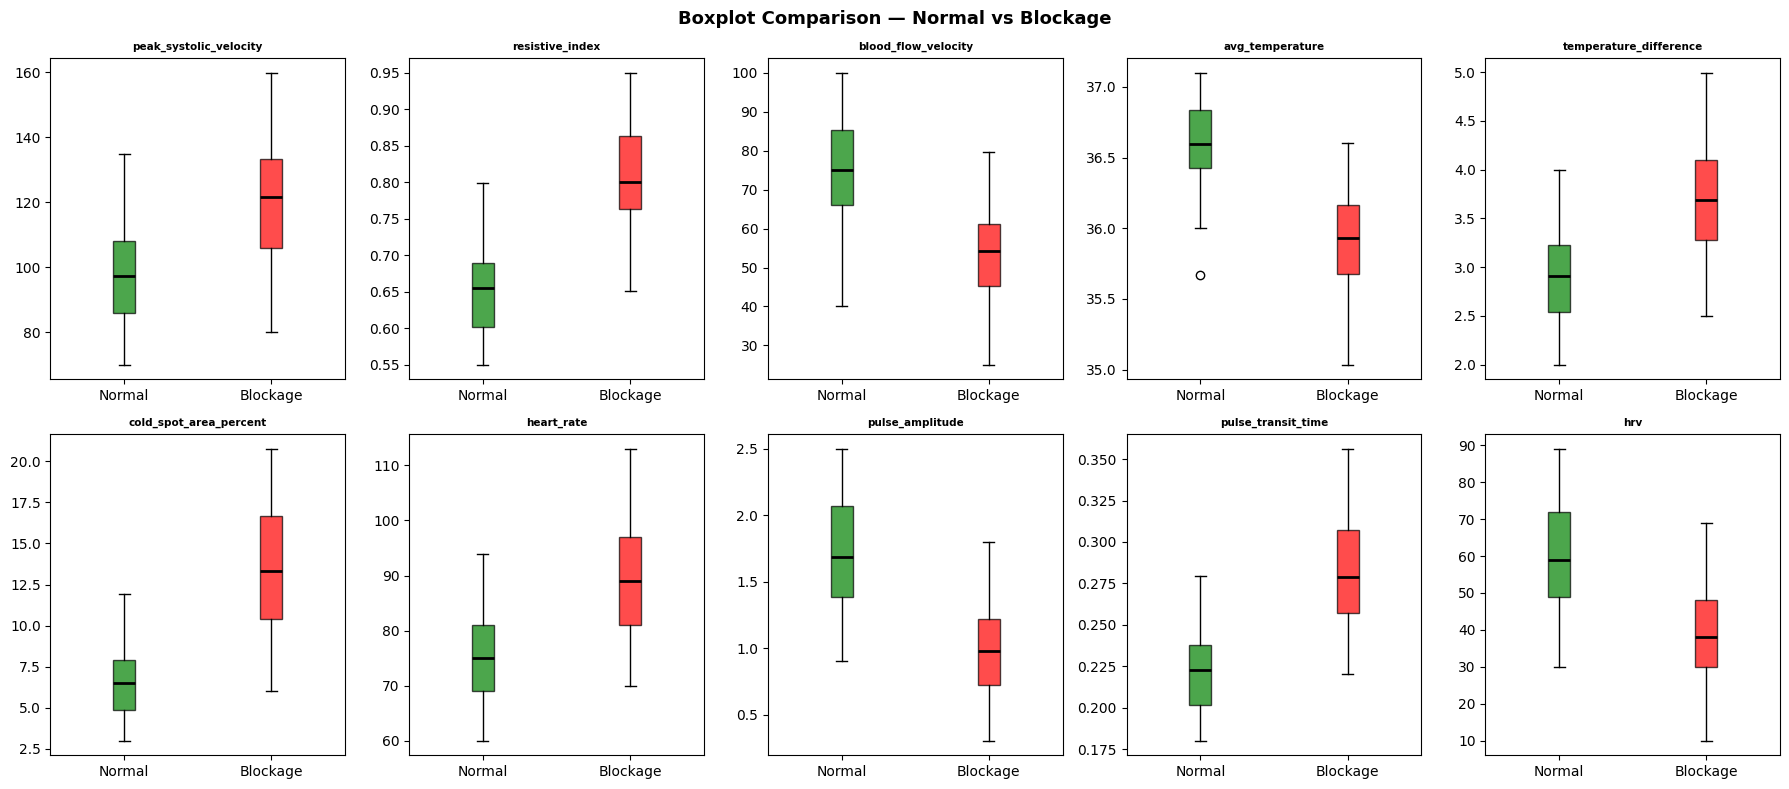

In [28]:
# Boxplot comparison — Normal vs Blockage
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(original_features):
    data_to_plot = [normal[col].values, blockage[col].values]
    bp = axes[i].boxplot(data_to_plot, patch_artist=True, labels=['Normal', 'Blockage'],
                         boxprops=dict(alpha=0.7),
                         medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][1].set_facecolor('red')
    axes[i].set_title(col, fontsize=7.5, fontweight='bold')

plt.suptitle('Boxplot Comparison — Normal vs Blockage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 8 — Sensitivity Analysis (Threshold Testing)

**Different thresholds test karo — kitne blockage cases milte hain?**

In [29]:
# Test different score thresholds
sensitivity_results = []

for thresh in range(1, 12):
    labels = (df['blockage_score'] >= thresh).astype(int)
    blockage_count = labels.sum()
    blockage_pct   = labels.mean() * 100
    sensitivity_results.append({
        'Score Threshold'  : thresh,
        'Blockage Patients': blockage_count,
        'Blockage %'       : round(blockage_pct, 1),
        'Normal %'         : round(100 - blockage_pct, 1)
    })

sens_df = pd.DataFrame(sensitivity_results)
print('Sensitivity Analysis:')
sens_df

Sensitivity Analysis:


,Score Threshold,Blockage Patients,Blockage %,Normal %
0,1,1347,67.4,32.7
1,2,1293,64.6,35.4
2,3,972,48.6,51.4
3,4,847,42.4,57.6
4,5,733,36.6,63.4
5,6,646,32.3,67.7
6,7,587,29.4,70.6
7,8,499,25.0,75.0
8,9,415,20.8,79.2
9,10,295,14.8,85.2


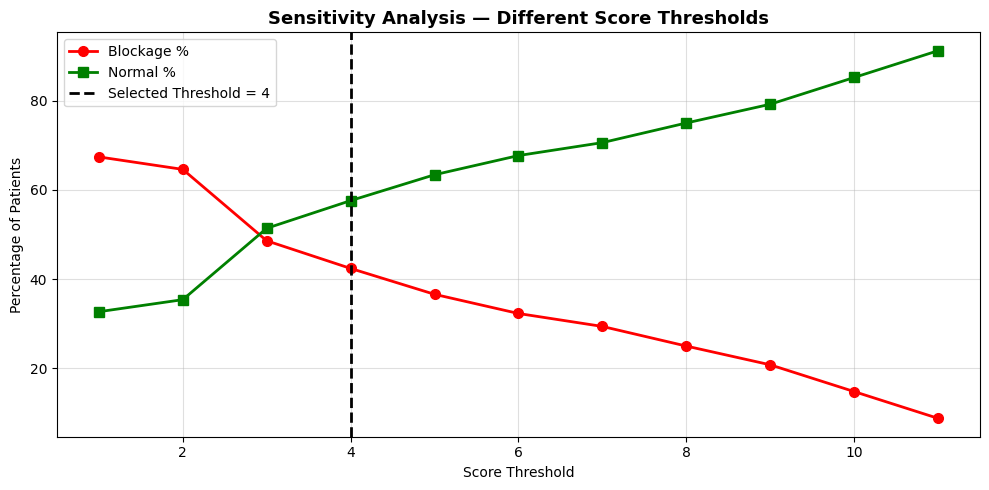

In [30]:
# Sensitivity plot
plt.figure(figsize=(10, 5))
plt.plot(sens_df['Score Threshold'], sens_df['Blockage %'],
         marker='o', color='red', linewidth=2, markersize=7, label='Blockage %')
plt.plot(sens_df['Score Threshold'], sens_df['Normal %'],
         marker='s', color='green', linewidth=2, markersize=7, label='Normal %')
plt.axvline(x=BLOCKAGE_THRESHOLD, color='black', linestyle='--', linewidth=2,
            label=f'Selected Threshold = {BLOCKAGE_THRESHOLD}')
plt.xlabel('Score Threshold')
plt.ylabel('Percentage of Patients')
plt.title('Sensitivity Analysis — Different Score Thresholds', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 9 — Final Label Overview

In [31]:
# Sample patients with labels
display_cols = ['peak_systolic_velocity', 'resistive_index',
                'blood_flow_velocity', 'cold_spot_area_percent',
                'blockage_score', 'blockage_label', 'confidence']

print('Sample Normal patients:')
df[df['blockage_label'] == 0][display_cols].head(5)

Sample Normal patients:


,peak_systolic_velocity,resistive_index,blood_flow_velocity,cold_spot_area_percent,blockage_score,blockage_label,confidence
0,83.085284,0.696231,96.250183,6.796991,0,0,High
4,105.756839,0.696231,70.038666,5.616955,0,0,High
5,105.391755,0.631531,63.269014,3.828873,2,0,Medium
6,93.114778,0.611765,86.038939,5.562513,0,0,High
10,74.701805,0.603501,90.299275,6.213373,0,0,High


In [32]:
print('Sample Blockage patients:')
df[df['blockage_label'] == 1][display_cols].head(5)

Sample Blockage patients:


,peak_systolic_velocity,resistive_index,blood_flow_velocity,cold_spot_area_percent,blockage_score,blockage_label,confidence
1,129.254272,0.853361,64.919065,20.324207,12,1,High
2,105.756839,0.836293,64.084861,10.418063,7,1,Medium
3,133.971340,0.688480,69.625238,8.783595,4,1,Low
7,102.081827,0.783621,44.117659,14.155087,9,1,High
8,94.052134,0.791996,66.805468,9.315082,4,1,Low


In [33]:
# Risk level assign karo
def get_risk_level(score):
    if score <= 1:   return 'Low Risk'
    elif score <= 3: return 'Moderate Risk'
    elif score <= 6: return 'High Risk'
    else:            return 'Critical Risk'

df['risk_level'] = df['blockage_score'].apply(get_risk_level)

print('Risk level distribution:')
df['risk_level'].value_counts()

Risk level distribution:


,count
risk_level,
Low Risk,707
Critical Risk,587
Moderate Risk,446
High Risk,260


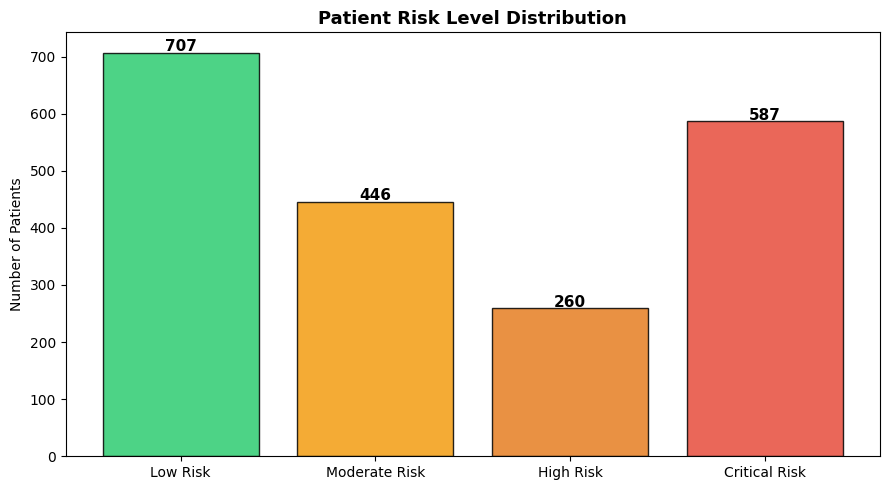

In [34]:
# Risk level visualization
risk_counts = df['risk_level'].value_counts()
risk_order  = ['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']
risk_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

plt.figure(figsize=(9, 5))
vals = [risk_counts.get(r, 0) for r in risk_order]
bars = plt.bar(risk_order, vals, color=risk_colors, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', fontsize=11, fontweight='bold')

plt.title('Patient Risk Level Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

---
## Step 10 — Save Labeled Data

In [35]:
# Save complete labeled dataset
df.to_csv('phase2_labeled_data.csv', index=False)

# Save only X (features) and y (labels) separately
feature_cols = [c for c in df.columns
                if c not in ['blockage_score', 'blockage_label', 'confidence', 'risk_level']]
X = df[feature_cols].values
y = df['blockage_label'].values

np.save('phase2_X.npy', X)
np.save('phase2_y.npy', y)

# Save feature column names
with open('phase2_feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print('Files saved:')
print('  phase2_labeled_data.csv  ← Full dataset with labels')
print('  phase2_X.npy             ← Features array')
print('  phase2_y.npy             ← Labels array (0=Normal, 1=Blockage)')
print('  phase2_feature_cols.pkl  ← Feature column names')
print()
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Files saved:
  phase2_labeled_data.csv  ← Full dataset with labels
  phase2_X.npy             ← Features array
  phase2_y.npy             ← Labels array (0=Normal, 1=Blockage)
  phase2_feature_cols.pkl  ← Feature column names

X shape: (2000, 15)
y shape: (2000,)


In [37]:
from google.colab import files

files.download('phase2_labeled_data.csv')
files.download('phase2_X.npy')
files.download('phase2_y.npy')
files.download('phase2_feature_cols.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Phase 2 Summary

In [ ]:
normal_count   = (y == 0).sum()
blockage_count = (y == 1).sum()

print('========================================')
print('  PHASE 2 — COMPLETE')
print('========================================')
print(f'Total patients    : {len(y)}')
print(f'Normal   (label=0): {normal_count} ({normal_count/len(y)*100:.1f}%)')
print(f'Blockage (label=1): {blockage_count} ({blockage_count/len(y)*100:.1f}%)')
print(f'Features used     : {X.shape[1]}')
print(f'Labeling method   : Weighted clinical scoring (threshold=4)')
print(f'Confidence levels : High / Medium / Low')
print(f'Risk levels       : Low / Moderate / High / Critical')
print('========================================')
print('  NEXT → PHASE 3: MLP Deep Network')
print('========================================')